# Comparing several cavities

A `Study` holds many cavities and runs an analysis across all of them, so the result namespaces offer **comparison plots** — every cavity's figures of merit side by side. Here we sweep the iris radius of a single-cell elliptical cavity and compare how the fundamental-mode QOIs respond.

In [1]:
import matplotlib.pyplot as plt
from cavsim2d import Study, EllipticalCavity
from cavsim2d.utils.style import apply_style
apply_style()

## 1. A study of three iris radii

The mid-cell template is the TESLA cell; we vary only the iris radius `Ri` (index 4 of `[A, B, a, b, Ri, L, Req]`).

In [2]:
base = [42, 42, 12, 19, 35, 57.652, 103.3536]
study = Study('compare_demo')
cavs, names = [], []
for Ri in (30, 35, 40):
    cell = base.copy(); cell[4] = Ri
    cavs.append(EllipticalCavity(1, cell, cell, cell, beampipe='both',
                                 name=f'Ri{Ri}'))
    names.append(f'Ri = {Ri} mm')
study.add_cavity(cavs, names)

## 2. Solve them all

One call runs the eigenmode analysis for every cavity in the study.

In [3]:
study.run_eigenmode({'processes': 1, 'boundary_conditions': 'mm',
                     'mesh_config': {'h': 10, 'p': 2}})

## 3. Compare the figures of merit

`study.eigenmode.plot_fm_scatter()` overlays each cavity's fundamental-mode QOIs. A wider iris lowers the frequency and R/Q and raises the peak-field ratios — the classic aperture trade-off.

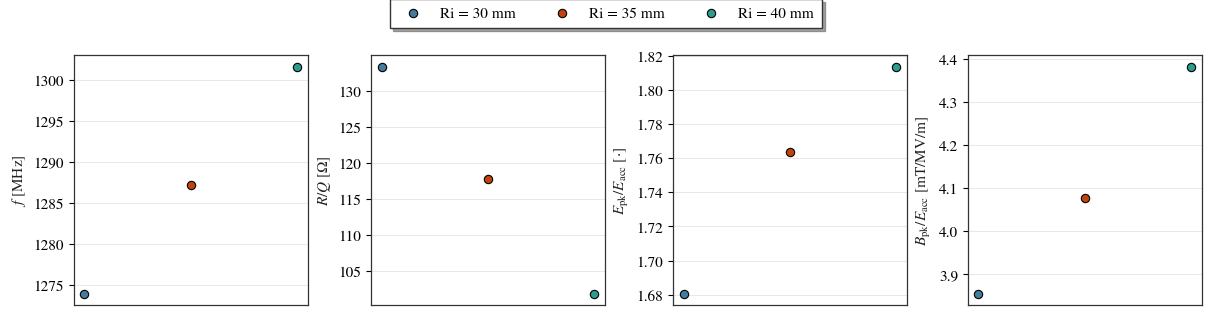

{'freq [MHz]': <Axes: label='freq [MHz]', ylabel='$f$ [MHz]'>,
 'R/Q [Ohm]': <Axes: label='R/Q [Ohm]', ylabel='$R/Q ~\\mathrm{[\\Omega]}$'>,
 'Epk/Eacc []': <Axes: label='Epk/Eacc []', ylabel='$E_\\mathrm{pk}/E_\\mathrm{acc} ~[\\cdot]$'>,
 'Bpk/Eacc [mT/MV/m]': <Axes: label='Bpk/Eacc [mT/MV/m]', ylabel='$B_\\mathrm{pk}/E_\\mathrm{acc} ~\\mathrm{[mT/MV/m]}$'>}

In [4]:
study.eigenmode.plot_fm_scatter(qois=['freq [MHz]', 'R/Q [Ohm]',
                                      'Epk/Eacc []', 'Bpk/Eacc [mT/MV/m]'])

## 4. The same data as bars


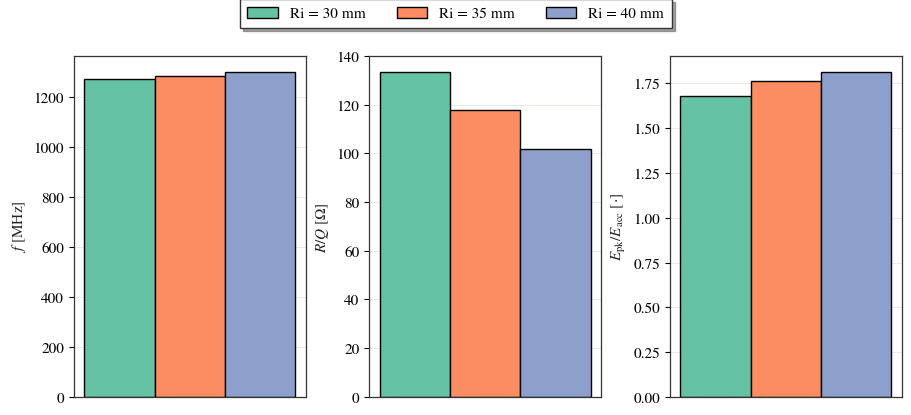

{'freq [MHz]': <Axes: label='freq [MHz]', ylabel='$f$ [MHz]'>,
 'R/Q [Ohm]': <Axes: label='R/Q [Ohm]', ylabel='$R/Q ~\\mathrm{[\\Omega]}$'>,
 'Epk/Eacc []': <Axes: label='Epk/Eacc []', ylabel='$E_\\mathrm{pk}/E_\\mathrm{acc} ~[\\cdot]$'>}

In [5]:
study.eigenmode.plot_fm_bar(qois=['freq [MHz]', 'R/Q [Ohm]', 'Epk/Eacc []'])

## Where to go next

- `study.eigenmode.plot_fm_scatter(uq=True)` adds ±1σ error bars when the cavities were run with a `uq_config` — see [Eigenmode under uncertainty](../advanced/eigenmode_uq.ipynb).
- `study.wakefield.plot_hom_scatter(...)` and `Study.plot_all_scatter(...)` compare wakefield and cross-domain QOIs the same way.